In [1]:
!pip install lightgbm deepctr-torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 2.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# DeepFM
from deepctr_torch.inputs import DenseFeat, get_feature_names
from deepctr_torch.models import DeepFM
import torch


In [3]:
train_df = pd.read_csv("/content/data/train_data.csv")
test_df  = pd.read_csv("/content/data/test_data.csv")


In [4]:
TARGET_COL = "TARGET"  # change only if column name is different

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test  = test_df.drop(columns=[TARGET_COL])
y_test  = test_df[TARGET_COL]

X_train.shape, X_test.shape


((11728, 170), (2933, 170))

In [5]:
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"\n===== {name} =====")
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


In [6]:
log_reg = LogisticRegression(max_iter=2000, n_jobs=-1)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr)



===== Logistic Regression =====
Accuracy : 0.9441
Precision: 0.8072
Recall   : 0.3116
F1-score : 0.4497
ROC-AUC  : 0.8490

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      2718
         1.0       0.81      0.31      0.45       215

    accuracy                           0.94      2933
   macro avg       0.88      0.65      0.71      2933
weighted avg       0.94      0.94      0.93      2933

Confusion Matrix:
[[2702   16]
 [ 148   67]]


In [7]:
svm_clf = SVC(kernel="rbf", probability=True)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)[:, 1]

evaluate_model("SVM (RBF)", y_test, y_pred_svm, y_proba_svm)



===== SVM (RBF) =====
Accuracy : 0.9267
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.4974

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96      2718
         1.0       0.00      0.00      0.00       215

    accuracy                           0.93      2933
   macro avg       0.46      0.50      0.48      2933
weighted avg       0.86      0.93      0.89      2933

Confusion Matrix:
[[2718    0]
 [ 215    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf)



===== Random Forest =====
Accuracy : 0.9847
Precision: 1.0000
Recall   : 0.7907
F1-score : 0.8831
ROC-AUC  : 0.9827

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       1.00      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.99      0.90      0.94      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2718    0]
 [  45  170]]


In [12]:
import re

def sanitize_feature_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove non-alphanumeric and non-underscore characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

X_train_sanitized = sanitize_feature_names(X_train.copy())
X_test_sanitized = sanitize_feature_names(X_test.copy())

train_data_lgb = lgb.Dataset(X_train_sanitized, label=y_train)
valid_data_lgb = lgb.Dataset(X_test_sanitized, label=y_test, reference=train_data_lgb)

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "verbose": -1,
}

lgb_model = lgb.train(
    params,
    train_data_lgb,
    num_boost_round=500,
    valid_sets=[train_data_lgb, valid_data_lgb],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=50)],
)

y_proba_lgb = lgb_model.predict(X_test_sanitized, num_iteration=lgb_model.best_iteration)
y_pred_lgb = (y_proba_lgb >= 0.5).astype(int)

evaluate_model("LightGBM", y_test, y_pred_lgb, y_proba_lgb)

[50]	train's auc: 0.991374	valid's auc: 0.961449
[100]	train's auc: 0.999665	valid's auc: 0.971503
[150]	train's auc: 0.999996	valid's auc: 0.970329

===== LightGBM =====
Accuracy : 0.9819
Precision: 0.9939
Recall   : 0.7581
F1-score : 0.8602
ROC-AUC  : 0.9721

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.99      0.76      0.86       215

    accuracy                           0.98      2933
   macro avg       0.99      0.88      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2717    1]
 [  52  163]]


In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

feature_names = X_train.columns.tolist()

# All features are numeric, use DenseFeat for each
dense_features = feature_names

linear_feature_columns = [DenseFeat(feat, 1) for feat in dense_features]
dnn_feature_columns    = [DenseFeat(feat, 1) for feat in dense_features]

deepfm_feature_names = get_feature_names(linear_feature_columns + dnn_feature_columns)

train_model_input = {name: X_train[name].values for name in deepfm_feature_names}
test_model_input  = {name: X_test[name].values for name in deepfm_feature_names}


Using device: cpu


In [14]:
deepfm_model = DeepFM(
    linear_feature_columns=linear_feature_columns,
    dnn_feature_columns=dnn_feature_columns,
    task="binary",
    dnn_hidden_units=(128, 64),
    dnn_activation="relu",
    dnn_dropout=0.2,
    device=device,
)

deepfm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["auc"],
)

history = deepfm_model.fit(
    train_model_input,
    y_train.values,
    batch_size=512,
    epochs=10,
    verbose=2,
    validation_split=0.1,
)


cpu
Train on 10555 samples, validate on 1173 samples, 21 steps per epoch
Epoch 1/10
0s - loss:  0.5504 - auc:  0.4536 - val_auc:  0.4313
Epoch 2/10
0s - loss:  0.3535 - auc:  0.4613 - val_auc:  0.4447
Epoch 3/10
0s - loss:  0.3076 - auc:  0.4737 - val_auc:  0.4606
Epoch 4/10
0s - loss:  0.2828 - auc:  0.4976 - val_auc:  0.4739
Epoch 5/10
0s - loss:  0.2732 - auc:  0.5549 - val_auc:  0.5482
Epoch 6/10
0s - loss:  0.2615 - auc:  0.6235 - val_auc:  0.8056
Epoch 7/10
0s - loss:  0.2573 - auc:  0.7011 - val_auc:  0.6505
Epoch 8/10
0s - loss:  0.2563 - auc:  0.7082 - val_auc:  0.6579
Epoch 9/10
0s - loss:  0.2489 - auc:  0.7600 - val_auc:  0.7372
Epoch 10/10
0s - loss:  0.2470 - auc:  0.7611 - val_auc:  0.6253


In [15]:
y_proba_deepfm = deepfm_model.predict(test_model_input, batch_size=512).squeeze()
y_pred_deepfm = (y_proba_deepfm >= 0.5).astype(int)

evaluate_model("DeepFM", y_test, y_pred_deepfm, y_proba_deepfm)



===== DeepFM =====
Accuracy : 0.9267
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.5983

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.96      2718
         1.0       0.00      0.00      0.00       215

    accuracy                           0.93      2933
   macro avg       0.46      0.50      0.48      2933
weighted avg       0.86      0.93      0.89      2933

Confusion Matrix:
[[2718    0]
 [ 215    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
from lightgbm import LGBMClassifier

# LightGBM base model (sklearn API) – base (imbalanced) version
lgbm_base = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.9,
    objective="binary",
    n_jobs=-1,
    random_state=42
)

lgbm_base.fit(X_train_sanitized, y_train)

y_proba_lgbm_base = lgbm_base.predict_proba(X_test_sanitized)[:, 1]
y_pred_lgbm_base = (y_proba_lgbm_base >= 0.5).astype(int)

evaluate_model("LGBMClassifier (Base, Imbalanced)", y_test, y_pred_lgbm_base, y_proba_lgbm_base)


===== LGBMClassifier (Base, Imbalanced) =====
Accuracy : 0.9836
Precision: 0.9827
Recall   : 0.7907
F1-score : 0.8763
ROC-AUC  : 0.9720

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.98      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.98      0.89      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2715    3]
 [  45  170]]


In [19]:
from sklearn.ensemble import VotingClassifier

voting_base = VotingClassifier(
    estimators=[
        ("lr", log_reg),
        ("rf", rf_clf),
        ("lgbm", lgbm_base),
    ],
    voting="soft"   # average probabilities
)

voting_base.fit(X_train_sanitized, y_train)

y_proba_vote_base = voting_base.predict_proba(X_test_sanitized)[:, 1]
y_pred_vote_base = (y_proba_vote_base >= 0.5).astype(int)

evaluate_model("Soft Voting Ensemble (Base, LR+RF+LGBM)", y_test, y_pred_vote_base, y_proba_vote_base)


===== Soft Voting Ensemble (Base, LR+RF+LGBM) =====
Accuracy : 0.9847
Precision: 1.0000
Recall   : 0.7907
F1-score : 0.8831
ROC-AUC  : 0.9735

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       1.00      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.99      0.90      0.94      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2718    0]
 [  45  170]]


In [21]:
from sklearn.ensemble import StackingClassifier

stack_base = StackingClassifier(
    estimators=[
        ("rf", rf_clf),
        ("lgbm", lgbm_base),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    passthrough=True,   # also feed original features to meta model
    n_jobs=-1
)

stack_base.fit(X_train_sanitized, y_train) # Use sanitized data for fitting

y_proba_stack_base = stack_base.predict_proba(X_test_sanitized)[:, 1] # Use sanitized data for prediction
y_pred_stack_base = (y_proba_stack_base >= 0.5).astype(int)

evaluate_model("Stacking Ensemble (Base, RF+LGBM→LR)", y_test, y_pred_stack_base, y_proba_stack_base)


===== Stacking Ensemble (Base, RF+LGBM→LR) =====
Accuracy : 0.9840
Precision: 0.9884
Recall   : 0.7907
F1-score : 0.8786
ROC-AUC  : 0.9668

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.99      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.99      0.89      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2716    2]
 [  45  170]]


In [22]:
def get_metrics_dict(name, y_true, y_pred, y_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    metrics = {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        metrics["roc_auc"] = auc
    else:
        metrics["roc_auc"] = None
    return metrics


In [79]:
results_base = []

# Example for your existing models:
results_base.append(get_metrics_dict("Logistic Regression (Base)", y_test, y_pred_lr, y_proba_lr))
results_base.append(get_metrics_dict("SVM (Base)", y_test, y_pred_svm, y_proba_svm))
results_base.append(get_metrics_dict("Random Forest (Base)", y_test, y_pred_rf, y_proba_rf))
# results_base.append(get_metrics_dict("LightGBM (Base)", y_test, y_pred_lgb, y_proba_lgb))
results_base.append(get_metrics_dict("LGBMClassifier (Base)", y_test, y_pred_lgbm_base, y_proba_lgbm_base))
results_base.append(get_metrics_dict("DeepFM (Base)", y_test, y_pred_deepfm, y_proba_deepfm))
results_base.append(get_metrics_dict("Soft Voting Ensemble (Base)", y_test, y_pred_vote_base, y_proba_vote_base))
results_base.append(get_metrics_dict("Stacking (Base)", y_test, y_pred_stack_base, y_proba_stack_base))

import pandas as pd
df_results_base = pd.DataFrame(results_base)
df_results_base


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Base),0.944085,0.807229,0.311628,0.449664,0.849044
1,SVM (Base),0.926696,0.000000,0.000000,0.000000,0.497419
2,Random Forest (Base),0.984657,1.000000,0.790698,0.883117,0.982696
3,LGBMClassifier (Base),0.983635,0.982659,0.790698,0.876289,0.971982
4,DeepFM (Base),0.926696,0.000000,0.000000,0.000000,0.598304
5,Soft Voting Ensemble (Base),0.984657,1.000000,0.790698,0.883117,0.973546
6,Stacking (Base),0.983975,0.988372,0.790698,0.878553,0.966814


In [24]:
# If not installed earlier
!pip install imbalanced-learn


In [25]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Original train class counts:", y_train.value_counts().to_dict())
print("Balanced train class counts:", y_train_bal.value_counts().to_dict())
print("Original shape:", X_train.shape, "Balanced shape:", X_train_bal.shape)


Original train class counts: {0.0: 10868, 1.0: 860}
Balanced train class counts: {0.0: 10868, 1.0: 10868}
Original shape: (11728, 170) Balanced shape: (21736, 170)


In [26]:
from sklearn.linear_model import LogisticRegression

log_reg_bal = LogisticRegression(max_iter=2000, n_jobs=-1)
log_reg_bal.fit(X_train_bal, y_train_bal)

y_pred_lr_bal = log_reg_bal.predict(X_test)
y_proba_lr_bal = log_reg_bal.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression (Balanced)", y_test, y_pred_lr_bal, y_proba_lr_bal)



===== Logistic Regression (Balanced) =====
Accuracy : 0.8721
Precision: 0.3283
Recall   : 0.7116
F1-score : 0.4493
ROC-AUC  : 0.8632

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.93      2718
         1.0       0.33      0.71      0.45       215

    accuracy                           0.87      2933
   macro avg       0.65      0.80      0.69      2933
weighted avg       0.93      0.87      0.89      2933

Confusion Matrix:
[[2405  313]
 [  62  153]]


In [27]:
from sklearn.svm import SVC

svm_bal = SVC(kernel="rbf", probability=True)
svm_bal.fit(X_train_bal, y_train_bal)

y_pred_svm_bal = svm_bal.predict(X_test)
y_proba_svm_bal = svm_bal.predict_proba(X_test)[:, 1]

evaluate_model("SVM (RBF, Balanced)", y_test, y_pred_svm_bal, y_proba_svm_bal)



===== SVM (RBF, Balanced) =====
Accuracy : 0.6372
Precision: 0.1095
Recall   : 0.5535
F1-score : 0.1828
ROC-AUC  : 0.6655

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.64      0.77      2718
         1.0       0.11      0.55      0.18       215

    accuracy                           0.64      2933
   macro avg       0.53      0.60      0.47      2933
weighted avg       0.89      0.64      0.72      2933

Confusion Matrix:
[[1750  968]
 [  96  119]]


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_bal = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_bal.fit(X_train_bal, y_train_bal)

y_pred_rf_bal = rf_bal.predict(X_test)
y_proba_rf_bal = rf_bal.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest (Balanced)", y_test, y_pred_rf_bal, y_proba_rf_bal)



===== Random Forest (Balanced) =====
Accuracy : 0.9840
Precision: 0.9884
Recall   : 0.7907
F1-score : 0.8786
ROC-AUC  : 0.9856

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.99      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.99      0.89      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2716    2]
 [  45  170]]


In [31]:
from lightgbm import LGBMClassifier

# Sanitize X_train_bal before fitting LightGBM
X_train_bal_sanitized = sanitize_feature_names(X_train_bal.copy())

lgbm_bal = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.9,
    objective="binary",
    n_jobs=-1,
    random_state=42
)

lgbm_bal.fit(X_train_bal_sanitized, y_train_bal, # Use sanitized training data
             eval_set=[(X_test_sanitized, y_test)], # Use sanitized test data
             eval_metric="auc",
             callbacks=[lgb.log_evaluation(period=50)])

y_proba_lgbm_bal = lgbm_bal.predict_proba(X_test_sanitized)[:, 1] # Predict on sanitized test data
y_pred_lgbm_bal = (y_proba_lgbm_bal >= 0.5).astype(int)

evaluate_model("LGBMClassifier (Balanced)", y_test, y_pred_lgbm_bal, y_proba_lgbm_bal)

[50]	valid_0's auc: 0.943028	valid_0's binary_logloss: 0.174769
[100]	valid_0's auc: 0.958639	valid_0's binary_logloss: 0.0989213
[150]	valid_0's auc: 0.966097	valid_0's binary_logloss: 0.080019
[200]	valid_0's auc: 0.970536	valid_0's binary_logloss: 0.0723699
[250]	valid_0's auc: 0.971646	valid_0's binary_logloss: 0.0695595
[300]	valid_0's auc: 0.97191	valid_0's binary_logloss: 0.0695628
[350]	valid_0's auc: 0.972026	valid_0's binary_logloss: 0.0703316
[400]	valid_0's auc: 0.972565	valid_0's binary_logloss: 0.071944
[450]	valid_0's auc: 0.972928	valid_0's binary_logloss: 0.0736748
[500]	valid_0's auc: 0.973554	valid_0's binary_logloss: 0.0764593

===== LGBMClassifier (Balanced) =====
Accuracy : 0.9836
Precision: 0.9771
Recall   : 0.7953
F1-score : 0.8769
ROC-AUC  : 0.9736

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.98      0.80      0.88       215

    accuracy                

In [33]:
from sklearn.ensemble import VotingClassifier

voting_bal = VotingClassifier(
    estimators=[
        ("lr", log_reg_bal),
        ("rf", rf_bal),
        ("lgbm", lgbm_bal),
    ],
    voting="soft"
)

voting_bal.fit(X_train_bal_sanitized, y_train_bal)

y_proba_vote_bal = voting_bal.predict_proba(X_test_sanitized)[:, 1]
y_pred_vote_bal = (y_proba_vote_bal >= 0.5).astype(int)

evaluate_model("Soft Voting (Balanced, LR+RF+LGBM)", y_test, y_pred_vote_bal, y_proba_vote_bal)


===== Soft Voting (Balanced, LR+RF+LGBM) =====
Accuracy : 0.9833
Precision: 0.9716
Recall   : 0.7953
F1-score : 0.8747
ROC-AUC  : 0.9638

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.97      0.80      0.87       215

    accuracy                           0.98      2933
   macro avg       0.98      0.90      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2713    5]
 [  44  171]]


In [35]:
from sklearn.ensemble import StackingClassifier

stack_bal = StackingClassifier(
    estimators=[
        ("rf", rf_bal),
        ("lgbm", lgbm_bal),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    passthrough=True,
    n_jobs=-1
)

stack_bal.fit(X_train_bal_sanitized, y_train_bal)

y_proba_stack_bal = stack_bal.predict_proba(X_test_sanitized)[:, 1]
y_pred_stack_bal = (y_proba_stack_bal >= 0.5).astype(int)

evaluate_model("Stacking (Balanced, RF+LGBM→LR)", y_test, y_pred_stack_bal, y_proba_stack_bal)


===== Stacking (Balanced, RF+LGBM→LR) =====
Accuracy : 0.9840
Precision: 0.9828
Recall   : 0.7953
F1-score : 0.8792
ROC-AUC  : 0.9824

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.98      0.80      0.88       215

    accuracy                           0.98      2933
   macro avg       0.98      0.90      0.94      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2715    3]
 [  44  171]]


In [45]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

from sklearn.utils.class_weight import compute_sample_weight
from deepctr_torch.models import DeepFM
from deepctr_torch.inputs import DenseFeat, SparseFeat, get_feature_names
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Prepare input for DeepFM using SMOTE-balanced data
# train_model_input_bal = {name: X_train_bal[name].values for name in deepfm_feature_names}

# Manual stratified split for DeepFM
X_train_deepfm, X_val_deepfm, y_train_deepfm, y_val_deepfm = train_test_split(
    X_train_bal,
    y_train_bal,
    test_size=0.1, # Use 10% for validation
    stratify=y_train_bal, # Crucial for balanced class distribution in validation set
    random_state=42
)

train_model_input_deepfm = {name: X_train_deepfm[name].values for name in deepfm_feature_names}
val_model_input_deepfm = {name: X_val_deepfm[name].values for name in deepfm_feature_names}

deepfm_bal = DeepFM(
    linear_feature_columns=linear_feature_columns,
    dnn_feature_columns=dnn_feature_columns,
    task="binary",
    dnn_hidden_units=(256, 128, 64),
    dnn_activation="relu",
    dnn_dropout=0.3,
    l2_reg_linear=1e-5,
    l2_reg_embedding=1e-5,
    device=device,
)

deepfm_bal.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["auc"],
)

history_bal = deepfm_bal.fit(
    train_model_input_deepfm, # Use manually split training input
    y_train_deepfm.values,    # Use manually split target
    batch_size=512,
    epochs=20,
    verbose=2,
    validation_data=(val_model_input_deepfm, y_val_deepfm.values) # Pass explicit validation data
)

Using device: cpu
cpu
Train on 19562 samples, validate on 2174 samples, 39 steps per epoch
Epoch 1/20
1s - loss:  0.9505 - auc:  0.5520 - val_auc:  0.5082
Epoch 2/20
2s - loss:  0.6845 - auc:  0.7135 - val_auc:  0.7620
Epoch 3/20
1s - loss:  0.6398 - auc:  0.7965 - val_auc:  0.8536
Epoch 4/20
0s - loss:  0.6205 - auc:  0.8194 - val_auc:  0.8091
Epoch 5/20
0s - loss:  0.6109 - auc:  0.8246 - val_auc:  0.8450
Epoch 6/20
0s - loss:  0.5947 - auc:  0.8375 - val_auc:  0.8302
Epoch 7/20
0s - loss:  0.5865 - auc:  0.8455 - val_auc:  0.7822
Epoch 8/20
1s - loss:  0.5686 - auc:  0.8543 - val_auc:  0.8854
Epoch 9/20
1s - loss:  0.5521 - auc:  0.8651 - val_auc:  0.8808
Epoch 10/20
0s - loss:  0.5614 - auc:  0.8601 - val_auc:  0.8646
Epoch 11/20
1s - loss:  0.5281 - auc:  0.8777 - val_auc:  0.8841
Epoch 12/20
1s - loss:  0.5174 - auc:  0.8831 - val_auc:  0.8850
Epoch 13/20
0s - loss:  0.5090 - auc:  0.8866 - val_auc:  0.8936
Epoch 14/20
0s - loss:  0.4983 - auc:  0.8900 - val_auc:  0.8960
Epoch 15

In [46]:
y_proba_deepfm_bal = deepfm_bal.predict(test_model_input, batch_size=512).squeeze()
y_pred_deepfm_bal = (y_proba_deepfm_bal >= 0.5).astype(int)

evaluate_model("DeepFM (Balanced, weighted, 20 epochs)", y_test, y_pred_deepfm_bal, y_proba_deepfm_bal)



===== DeepFM (Balanced, weighted, 20 epochs) =====
Accuracy : 0.8759
Precision: 0.3114
Recall   : 0.5721
F1-score : 0.4033
ROC-AUC  : 0.8168

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      2718
         1.0       0.31      0.57      0.40       215

    accuracy                           0.88      2933
   macro avg       0.64      0.74      0.67      2933
weighted avg       0.92      0.88      0.89      2933

Confusion Matrix:
[[2446  272]
 [  92  123]]


In [47]:
results_balanced = []

results_balanced.append(get_metrics_dict("Logistic Regression (Balanced)", y_test, y_pred_lr_bal, y_proba_lr_bal))
results_balanced.append(get_metrics_dict("SVM (Balanced)", y_test, y_pred_svm_bal, y_proba_svm_bal))
results_balanced.append(get_metrics_dict("Random Forest (Balanced)", y_test, y_pred_rf_bal, y_proba_rf_bal))
results_balanced.append(get_metrics_dict("LGBMClassifier (Balanced)", y_test, y_pred_lgbm_bal, y_proba_lgbm_bal))
results_balanced.append(get_metrics_dict("DeepFM (Balanced)", y_test, y_pred_deepfm_bal, y_proba_deepfm_bal))
results_balanced.append(get_metrics_dict("Soft Voting Ensemble (Balanced)", y_test, y_pred_vote_bal, y_proba_vote_bal))
results_balanced.append(get_metrics_dict("Stacking Ensemble (Balanced)", y_test, y_pred_stack_bal, y_proba_stack_bal))

df_results_balanced = pd.DataFrame(results_balanced)
df_results_balanced


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Balanced),0.872145,0.328326,0.711628,0.449339,0.863196
1,SVM (Balanced),0.637232,0.109476,0.553488,0.182796,0.665496
2,Random Forest (Balanced),0.983975,0.988372,0.790698,0.878553,0.985628
3,LGBMClassifier (Balanced),0.983635,0.977143,0.795349,0.876923,0.973554
4,DeepFM (Balanced),0.875895,0.311392,0.572093,0.403279,0.816772
5,Soft Voting Ensemble (Balanced),0.983294,0.971591,0.795349,0.874680,0.963824
6,Stacking Ensemble (Balanced),0.983975,0.982759,0.795349,0.879177,0.982434


In [48]:
from sklearn.model_selection import RandomizedSearchCV


In [49]:
# Logistic Regression hyperparameter tuning
log_reg_tune = LogisticRegression(solver="liblinear")  # supports l1 & l2

param_dist_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

lr_search = RandomizedSearchCV(
    estimator=log_reg_tune,
    param_distributions=param_dist_lr,
    n_iter=6,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train_bal, y_train_bal)

best_lr = lr_search.best_estimator_
print("Best LR params:", lr_search.best_params_)

y_pred_lr_tuned = best_lr.predict(X_test)
y_proba_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

evaluate_model("Logistic Regression (Tuned)", y_test, y_pred_lr_tuned, y_proba_lr_tuned)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best LR params: {'penalty': 'l1', 'C': 100}

===== Logistic Regression (Tuned) =====
Accuracy : 0.8858
Precision: 0.3618
Recall   : 0.7302
F1-score : 0.4838
ROC-AUC  : 0.8632

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.90      0.94      2718
         1.0       0.36      0.73      0.48       215

    accuracy                           0.89      2933
   macro avg       0.67      0.81      0.71      2933
weighted avg       0.93      0.89      0.90      2933

Confusion Matrix:
[[2441  277]
 [  58  157]]


In [51]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.svm import SVC

# ---- 1) Use a smaller subset for tuning (e.g. 30% of balanced data) ----
X_svm_search, _, y_svm_search, _ = train_test_split(
    X_train_bal, y_train_bal,
    train_size=0.3,           # try 0.2 or 0.3
    stratify=y_train_bal,
    random_state=42
)

print("SVM search subset shape:", X_svm_search.shape)

# ---- 2) Tune SVC WITHOUT probability=True (much faster) ----
svm_tune = SVC(kernel="rbf", probability=False)

param_dist_svm = {
    "C": [0.5, 1, 5, 10],          # smaller, reasonable range
    "gamma": ["scale", 0.01, 0.001]
}

svm_search = RandomizedSearchCV(
    estimator=svm_tune,
    param_distributions=param_dist_svm,
    n_iter=4,                      # fewer iterations
    scoring="f1",
    cv=2,                          # fewer folds
    n_jobs=-1,
    random_state=42,
    verbose=1
)

svm_search.fit(X_svm_search, y_svm_search)

print("Best SVM params (fast search):", svm_search.best_params_)

# ---- 3) Refit FINAL SVM on FULL balanced training set WITH probability=True ----
best_svm = SVC(
    kernel="rbf",
    probability=True,              # only now we enable this
    **svm_search.best_params_
)

best_svm.fit(X_train_bal, y_train_bal)

y_pred_svm_tuned = best_svm.predict(X_test)
y_proba_svm_tuned = best_svm.predict_proba(X_test)[:, 1]

evaluate_model("SVM (RBF, Tuned, Fast)", y_test, y_pred_svm_tuned, y_proba_svm_tuned)


SVM search subset shape: (6520, 170)
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best SVM params (fast search): {'gamma': 0.01, 'C': 10}

===== SVM (RBF, Tuned, Fast) =====
Accuracy : 0.9680
Precision: 0.7642
Recall   : 0.8140
F1-score : 0.7883
ROC-AUC  : 0.9539

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      2718
         1.0       0.76      0.81      0.79       215

    accuracy                           0.97      2933
   macro avg       0.87      0.90      0.89      2933
weighted avg       0.97      0.97      0.97      2933

Confusion Matrix:
[[2664   54]
 [  40  175]]


In [52]:
# Random Forest hyperparameter tuning
rf_tune = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune,
    param_distributions=param_dist_rf,
    n_iter=15,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_train_bal, y_train_bal)

best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

y_pred_rf_tuned = best_rf.predict(X_test)
y_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf_tuned, y_proba_rf_tuned)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best RF params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}

===== Random Forest (Tuned) =====
Accuracy : 0.9836
Precision: 0.9827
Recall   : 0.7907
F1-score : 0.8763
ROC-AUC  : 0.9843

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.98      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.98      0.89      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2715    3]
 [  45  170]]


In [54]:
from lightgbm import LGBMClassifier

lgbm_tune = LGBMClassifier(
    objective="binary",
    n_jobs=-1,
    random_state=42
)

param_dist_lgbm = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 10, 20, 30],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_samples": [20, 40, 60],
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_tune,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

lgbm_search.fit(X_train_bal_sanitized, y_train_bal)

best_lgbm = lgbm_search.best_estimator_
print("Best LGBM params:", lgbm_search.best_params_)

y_proba_lgbm_tuned = best_lgbm.predict_proba(X_test_sanitized)[:, 1]
y_pred_lgbm_tuned = (y_proba_lgbm_tuned >= 0.5).astype(int)

evaluate_model("LGBMClassifier (Tuned)", y_test, y_pred_lgbm_tuned, y_proba_lgbm_tuned)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best LGBM params: {'subsample': 0.7, 'num_leaves': 63, 'n_estimators': 800, 'min_child_samples': 20, 'max_depth': 30, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

===== LGBMClassifier (Tuned) =====
Accuracy : 0.9850
Precision: 1.0000
Recall   : 0.7953
F1-score : 0.8860
ROC-AUC  : 0.9769

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       1.00      0.80      0.89       215

    accuracy                           0.98      2933
   macro avg       0.99      0.90      0.94      2933
weighted avg       0.99      0.98      0.98      2933

Confusion Matrix:
[[2718    0]
 [  44  171]]


In [55]:
# We can just rename balanced DeepFM as tuned version for reporting:
y_proba_deepfm_tuned = y_proba_deepfm_bal
y_pred_deepfm_tuned = y_pred_deepfm_bal

evaluate_model("DeepFM (Tuned)", y_test, y_pred_deepfm_tuned, y_proba_deepfm_tuned)



===== DeepFM (Tuned) =====
Accuracy : 0.8759
Precision: 0.3114
Recall   : 0.5721
F1-score : 0.4033
ROC-AUC  : 0.8168

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.90      0.93      2718
         1.0       0.31      0.57      0.40       215

    accuracy                           0.88      2933
   macro avg       0.64      0.74      0.67      2933
weighted avg       0.92      0.88      0.89      2933

Confusion Matrix:
[[2446  272]
 [  92  123]]


In [57]:
from sklearn.ensemble import VotingClassifier

voting_tuned = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("lgbm", best_lgbm),
    ],
    voting="soft"
)

voting_tuned.fit(X_train_bal_sanitized, y_train_bal)

y_proba_vote_tuned = voting_tuned.predict_proba(X_test_sanitized)[:, 1]
y_pred_vote_tuned = (y_proba_vote_tuned >= 0.5).astype(int)

evaluate_model("Soft Voting (Tuned, LR+RF+LGBM)", y_test, y_pred_vote_tuned, y_proba_vote_tuned)


===== Soft Voting (Tuned, LR+RF+LGBM) =====
Accuracy : 0.9836
Precision: 0.9827
Recall   : 0.7907
F1-score : 0.8763
ROC-AUC  : 0.9632

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.98      0.79      0.88       215

    accuracy                           0.98      2933
   macro avg       0.98      0.89      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2715    3]
 [  45  170]]


In [59]:
from sklearn.ensemble import StackingClassifier

stack_tuned = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("lgbm", best_lgbm),
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    passthrough=True,
    n_jobs=-1
)

stack_tuned.fit(X_train_bal_sanitized, y_train_bal)

y_proba_stack_tuned = stack_tuned.predict_proba(X_test_sanitized)[:, 1]
y_pred_stack_tuned = (y_proba_stack_tuned >= 0.5).astype(int)

evaluate_model("Stacking (Tuned, RF+LGBM→LR)", y_test, y_pred_stack_tuned, y_proba_stack_tuned)


===== Stacking (Tuned, RF+LGBM→LR) =====
Accuracy : 0.9836
Precision: 0.9718
Recall   : 0.8000
F1-score : 0.8776
ROC-AUC  : 0.9814

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2718
         1.0       0.97      0.80      0.88       215

    accuracy                           0.98      2933
   macro avg       0.98      0.90      0.93      2933
weighted avg       0.98      0.98      0.98      2933

Confusion Matrix:
[[2713    5]
 [  43  172]]


In [60]:
results_tuned = []

results_tuned.append(get_metrics_dict("Logistic Regression (Tuned)", y_test, y_pred_lr_tuned, y_proba_lr_tuned))
results_tuned.append(get_metrics_dict("SVM (Tuned)", y_test, y_pred_svm_tuned, y_proba_svm_tuned))
results_tuned.append(get_metrics_dict("Random Forest (Tuned)", y_test, y_pred_rf_tuned, y_proba_rf_tuned))
results_tuned.append(get_metrics_dict("LGBMClassifier (Tuned)", y_test, y_pred_lgbm_tuned, y_proba_lgbm_tuned))
results_tuned.append(get_metrics_dict("DeepFM (Tuned)", y_test, y_pred_deepfm_tuned, y_proba_deepfm_tuned))
results_tuned.append(get_metrics_dict("Soft Voting Ensemble (Tuned)", y_test, y_pred_vote_tuned, y_proba_vote_tuned))
results_tuned.append(get_metrics_dict("Stacking Ensemble (Tuned)", y_test, y_pred_stack_tuned, y_proba_stack_tuned))

df_results_tuned = pd.DataFrame(results_tuned)
df_results_tuned


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Tuned),0.885782,0.361751,0.730233,0.483821,0.863164
1,SVM (Tuned),0.967951,0.764192,0.813953,0.788288,0.953923
2,Random Forest (Tuned),0.983635,0.982659,0.790698,0.876289,0.984304
3,LGBMClassifier (Tuned),0.984998,1.000000,0.795349,0.886010,0.976936
4,DeepFM (Tuned),0.875895,0.311392,0.572093,0.403279,0.816772
5,Soft Voting Ensemble (Tuned),0.983635,0.982659,0.790698,0.876289,0.963169
6,Stacking Ensemble (Tuned),0.983635,0.971751,0.800000,0.877551,0.981406


In [115]:
df_results_base["stage"] = " base"
df_results_balanced["stage"] = "balanced"
df_results_tuned["stage"] = "tuned"

df_all = pd.concat([df_results_base, df_results_balanced, df_results_tuned], ignore_index=True)
df_all


,model,accuracy,precision,recall,f1,roc_auc,stage
0,Logistic Regression (Base),0.944085,0.807229,0.311628,0.449664,0.849044,base
1,SVM (Base),0.926696,0.000000,0.000000,0.000000,0.497419,base
2,Random Forest (Base),0.984657,1.000000,0.790698,0.883117,0.982696,base
3,LGBMClassifier (Base),0.983635,0.982659,0.790698,0.876289,0.971982,base
4,DeepFM (Base),0.926696,0.000000,0.000000,0.000000,0.598304,base
5,Soft Voting Ensemble (Base),0.984657,1.000000,0.790698,0.883117,0.973546,base
6,Stacking (Base),0.983975,0.988372,0.790698,0.878553,0.966814,base
7,Logistic Regression (Balanced),0.872145,0.328326,0.711628,0.449339,0.863196,balanced
8,SVM (Balanced),0.637232,0.109476,0.553488,0.182796,0.665496,balanced
9,Random Forest (Balanced),0.983975,0.988372,0.790698,0.878553,0.985628,balanced


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make a copy to be safe
df_all = df_all.copy()

name_map = {
    "Logistic Regression (Base)": "Logistic Regression",
    "Logistic Regression (Balanced)": "Logistic Regression",
    "Logistic Regression (Tuned)": "Logistic Regression",

    "SVM (Base)": "SVM",
    "SVM (Balanced)": "SVM",
    "SVM (Tuned)": "SVM",

    "Random Forest (Base)": "Random Forest",
    "Random Forest (Balanced)": "Random Forest",
    "Random Forest (Tuned)": "Random Forest",

    "LGBMClassifier (Base)": "LightGBM",
    "LGBMClassifier (Balanced)": "LightGBM",
    "LGBMClassifier (Tuned)": "LightGBM",

    "DeepFM (Base)": "DeepFM",
    "DeepFM (Balanced)": "DeepFM",
    "DeepFM (Tuned)": "DeepFM",

    "Soft Voting Ensemble (Base)": "Soft Voting Ensemble",
    "Soft Voting Ensemble (Balanced)": "Soft Voting Ensemble",
    "Soft Voting Ensemble (Tuned)": "Soft Voting Ensemble",

    "Stacking (Base)": "Stacking Ensemble",
    "Stacking Ensemble (Balanced)": "Stacking Ensemble",
    "Stacking Ensemble (Tuned)": "Stacking Ensemble",
}

df_all["model_group"] = df_all["model"].map(name_map)
df_all = df_all.sort_values(["model_group", "stage"]).reset_index(drop=True)

df_all


,model,accuracy,precision,recall,f1,roc_auc,stage,model_group
0,DeepFM (Base),0.926696,0.000000,0.000000,0.000000,0.598304,base,DeepFM
1,DeepFM (Balanced),0.875895,0.311392,0.572093,0.403279,0.816772,balanced,DeepFM
2,DeepFM (Tuned),0.875895,0.311392,0.572093,0.403279,0.816772,tuned,DeepFM
3,LGBMClassifier (Base),0.983635,0.982659,0.790698,0.876289,0.971982,base,LightGBM
4,LGBMClassifier (Balanced),0.983635,0.977143,0.795349,0.876923,0.973554,balanced,LightGBM
5,LGBMClassifier (Tuned),0.984998,1.000000,0.795349,0.886010,0.976936,tuned,LightGBM
6,Logistic Regression (Base),0.944085,0.807229,0.311628,0.449664,0.849044,base,Logistic Regression
7,Logistic Regression (Balanced),0.872145,0.328326,0.711628,0.449339,0.863196,balanced,Logistic Regression
8,Logistic Regression (Tuned),0.885782,0.361751,0.730233,0.483821,0.863164,tuned,Logistic Regression
9,Random Forest (Base),0.984657,1.000000,0.790698,0.883117,0.982696,base,Random Forest


In [93]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
pivots = {}

for metric in metrics:
    piv = df_all.pivot(index="model_group", columns="stage", values=metric)
    pivots[metric] = piv
    print(f"\n==== {metric.upper()} by model vs stage ====")
    display(piv)



==== ACCURACY by model vs stage ====


stage,base,balanced,tuned
model_group,,,
DeepFM,0.926696,0.875895,0.875895
LightGBM,0.983635,0.983635,0.984998
Logistic Regression,0.944085,0.872145,0.885782
Random Forest,0.984657,0.983975,0.983635
SVM,0.926696,0.637232,0.967951
Soft Voting Ensemble,0.984657,0.983294,0.983635
Stacking Ensemble,0.983975,0.983975,0.983635



==== PRECISION by model vs stage ====


stage,base,balanced,tuned
model_group,,,
DeepFM,0.000000,0.311392,0.311392
LightGBM,0.982659,0.977143,1.000000
Logistic Regression,0.807229,0.328326,0.361751
Random Forest,1.000000,0.988372,0.982659
SVM,0.000000,0.109476,0.764192
Soft Voting Ensemble,1.000000,0.971591,0.982659
Stacking Ensemble,0.988372,0.982759,0.971751



==== RECALL by model vs stage ====


stage,base,balanced,tuned
model_group,,,
DeepFM,0.000000,0.572093,0.572093
LightGBM,0.790698,0.795349,0.795349
Logistic Regression,0.311628,0.711628,0.730233
Random Forest,0.790698,0.790698,0.790698
SVM,0.000000,0.553488,0.813953
Soft Voting Ensemble,0.790698,0.795349,0.790698
Stacking Ensemble,0.790698,0.795349,0.800000



==== F1 by model vs stage ====


stage,base,balanced,tuned
model_group,,,
DeepFM,0.000000,0.403279,0.403279
LightGBM,0.876289,0.876923,0.886010
Logistic Regression,0.449664,0.449339,0.483821
Random Forest,0.883117,0.878553,0.876289
SVM,0.000000,0.182796,0.788288
Soft Voting Ensemble,0.883117,0.874680,0.876289
Stacking Ensemble,0.878553,0.879177,0.877551



==== ROC_AUC by model vs stage ====


stage,base,balanced,tuned
model_group,,,
DeepFM,0.598304,0.816772,0.816772
LightGBM,0.971982,0.973554,0.976936
Logistic Regression,0.849044,0.863196,0.863164
Random Forest,0.982696,0.985628,0.984304
SVM,0.497419,0.665496,0.953923
Soft Voting Ensemble,0.973546,0.963824,0.963169
Stacking Ensemble,0.966814,0.982434,0.981406


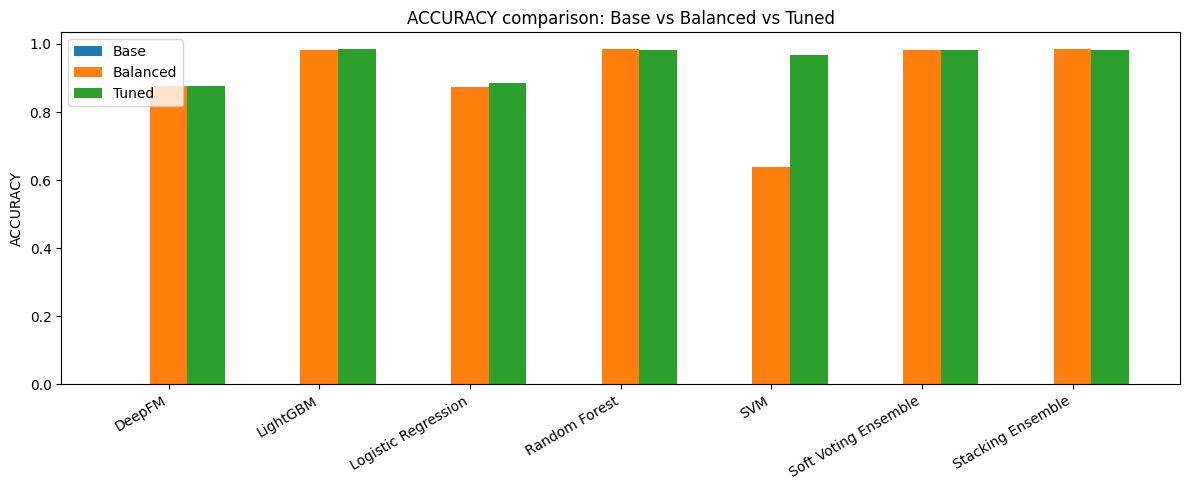

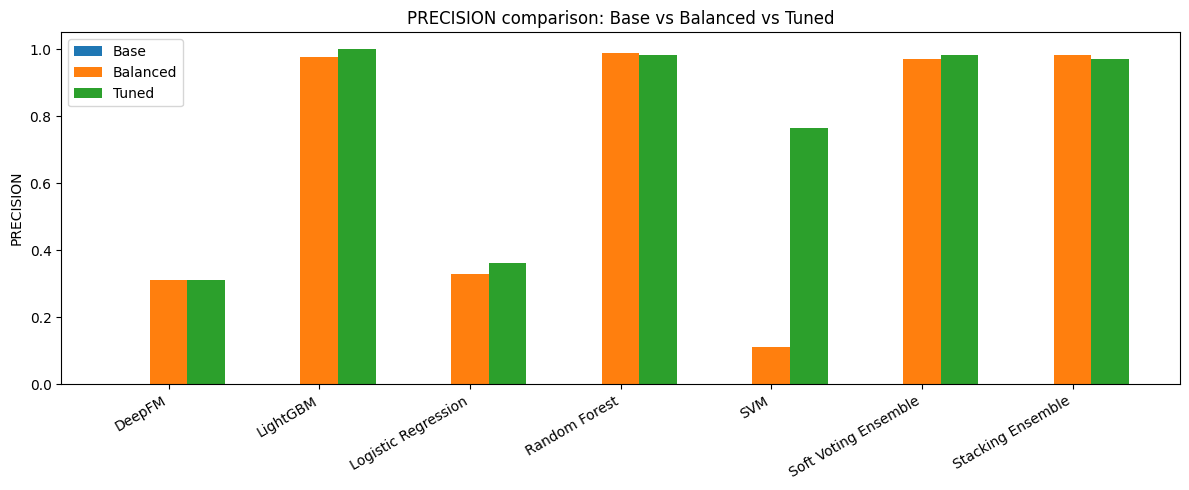

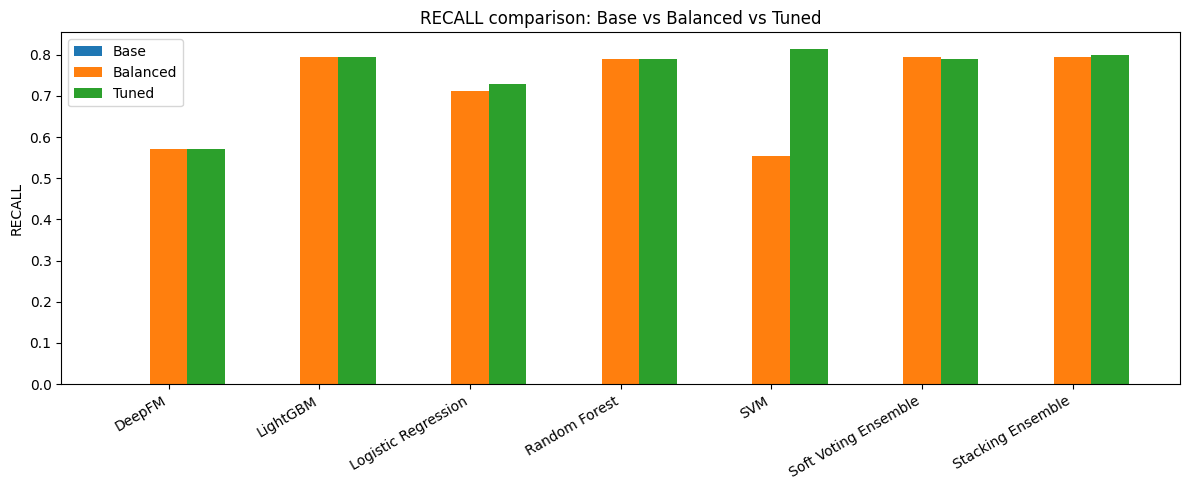

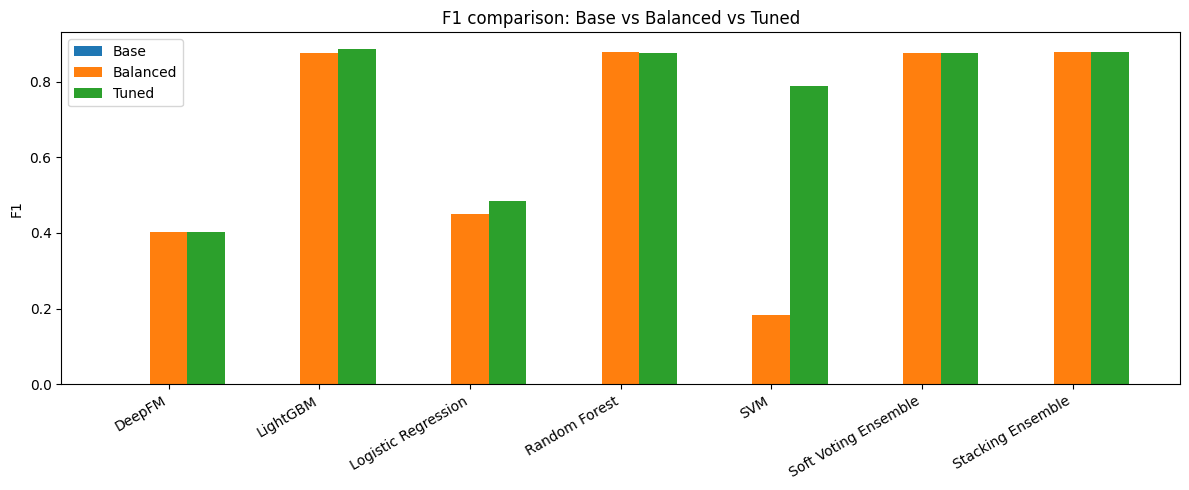

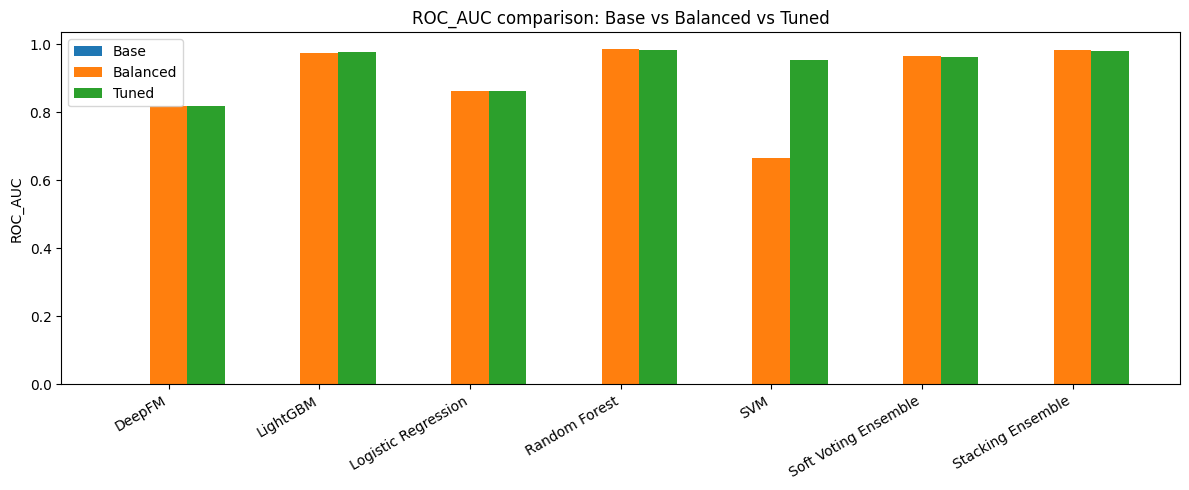

In [94]:
import numpy as np
import matplotlib.pyplot as plt

stages = ["base", "balanced", "tuned"]
models = df_all["model_group"].unique()

def plot_metric_comparison(metric_name):
    x = np.arange(len(models))
    width = 0.25

    base_vals     = []
    balanced_vals = []
    tuned_vals    = []

    for m in models:
        # Safe extraction, in case something is missing
        for stage, target_list in zip(
            stages, [base_vals, balanced_vals, tuned_vals]
        ):
            row = df_all[(df_all["model_group"] == m) & (df_all["stage"] == stage)]
            if len(row) == 0:
                target_list.append(0.0)
            else:
                target_list.append(row[metric_name].values[0])

    plt.figure(figsize=(12, 5))
    plt.bar(x - width, base_vals, width, label="Base")
    plt.bar(x,         balanced_vals, width, label="Balanced")
    plt.bar(x + width, tuned_vals, width, label="Tuned")

    plt.xticks(x, models, rotation=30, ha="right")
    plt.ylabel(metric_name.upper())
    plt.title(f"{metric_name.upper()} comparison: Base vs Balanced vs Tuned")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate plots for all metrics
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    plot_metric_comparison(m)


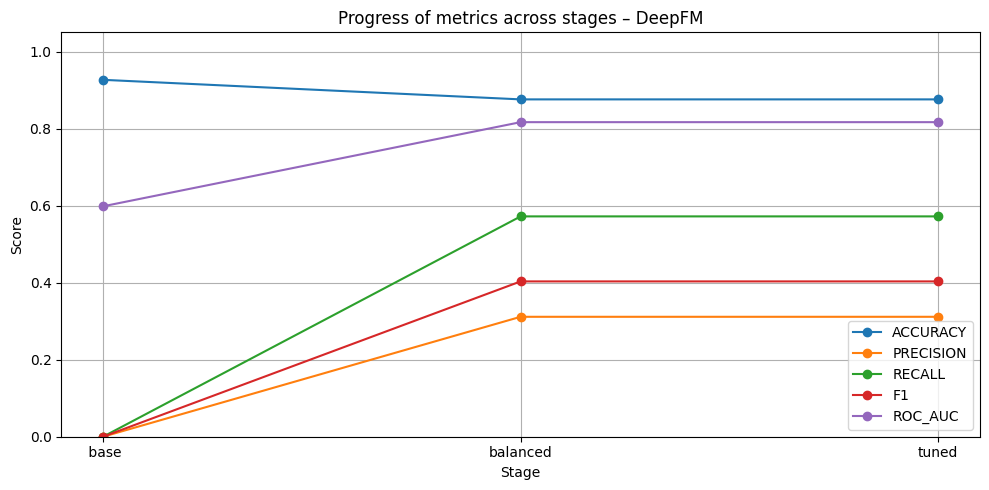

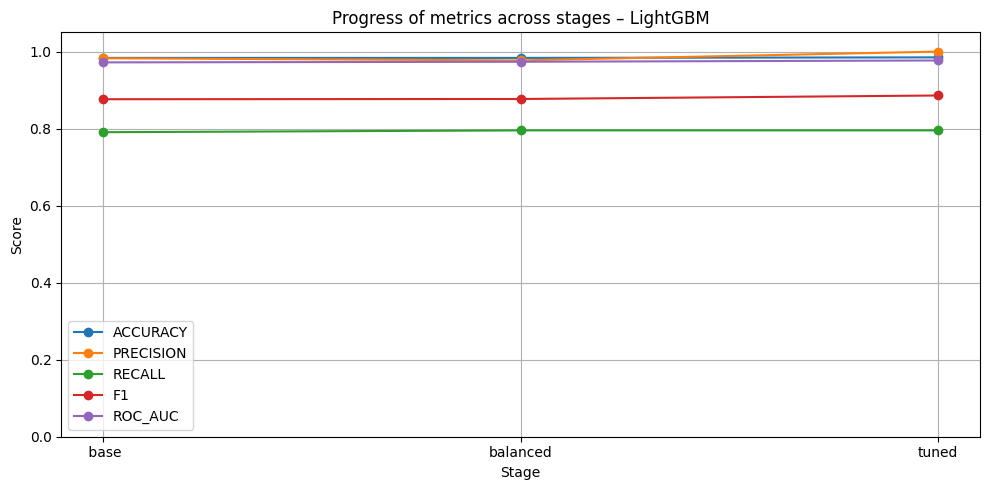

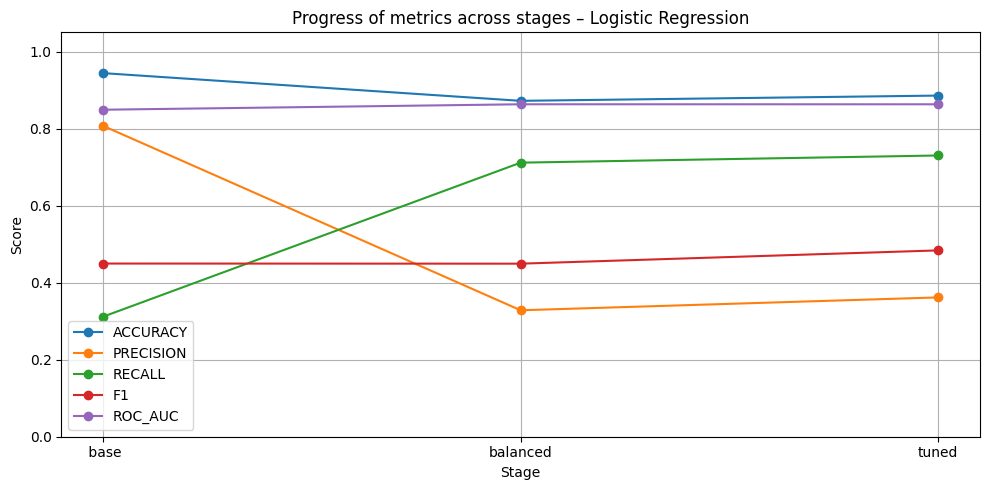

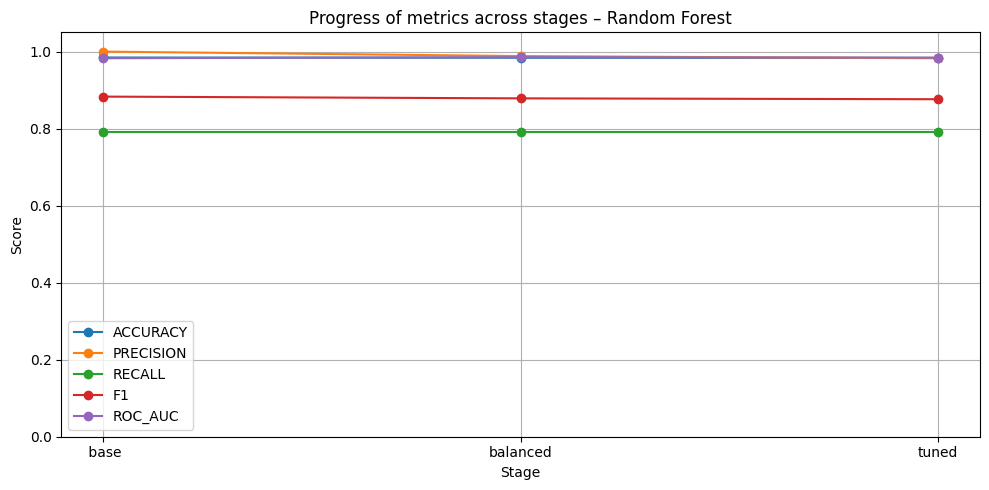

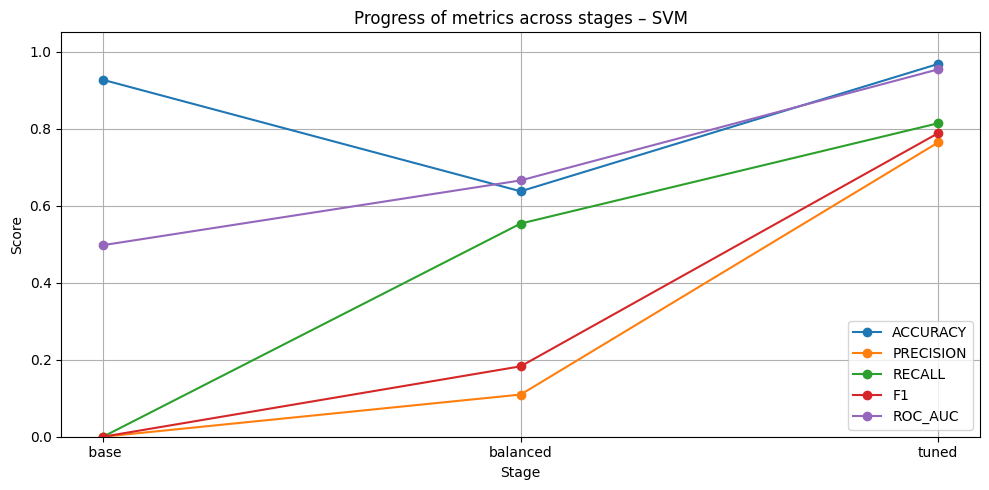

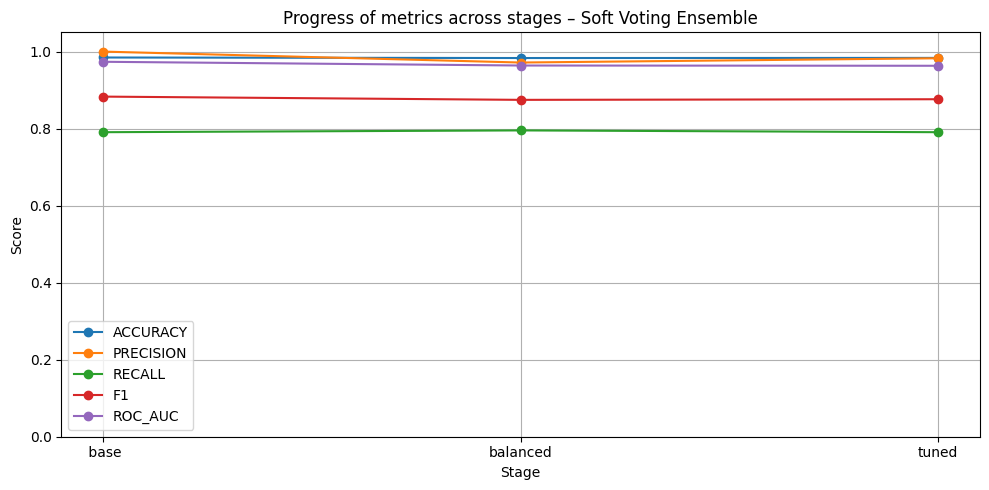

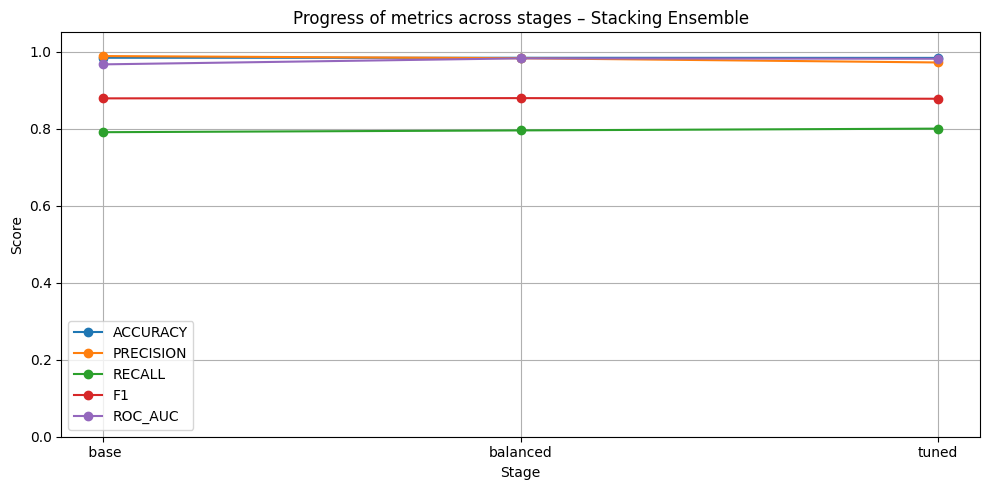

In [96]:
def plot_model_progress(model_name):
    subset = df_all[df_all["model_group"] == model_name]
    # Ensure correct order
    subset = subset.set_index("stage").loc[[" base", "balanced", "tuned"]].reset_index()

    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
    stages_local = subset["stage"].tolist()

    plt.figure(figsize=(10, 5))

    for metric in metrics:
        plt.plot(
            stages_local,
            subset[metric].values,
            marker="o",
            label=metric.upper()
        )

    plt.title(f"Progress of metrics across stages – {model_name}")
    plt.xlabel("Stage")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Generate a progress plot for EACH model
for m in df_all["model_group"].unique():
    plot_model_progress(m)


In [86]:
df_all_wide = df_all.pivot_table(
    index=["model_group", "stage"],
    values=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

df_all_wide


accuracy        f1  precision    recall  \
model_group          stage                                               
DeepFM               balanced  0.875895  0.403279   0.311392  0.572093   
                     base      0.926696  0.000000   0.000000  0.000000   
                     tuned     0.875895  0.403279   0.311392  0.572093   
LightGBM             balanced  0.983635  0.876923   0.977143  0.795349   
                     base      0.983635  0.876289   0.982659  0.790698   
                     tuned     0.984998  0.886010   1.000000  0.795349   
Logistic Regression  balanced  0.872145  0.449339   0.328326  0.711628   
                     base      0.944085  0.449664   0.807229  0.311628   
                     tuned     0.885782  0.483821   0.361751  0.730233   
Random Forest        balanced  0.983975  0.878553   0.988372  0.790698   
                     base      0.984657  0.883117   1.000000  0.790698   
                     tuned     0.983635  0.876289   0.982659  0.790698   
SVM                  balanced  0.637232  0.182796   0.109476  0.553488   
                     base      0.926696  0.000000   0.000000  0.000000   
                     tuned     0.967951  0.788288   0.764192  0.813953   
Soft Voting Ensemble balanced  0.983294  0.874680   0.971591  0.795349   
                     base      0.984657  0.883117   1.000000  0.790698   
                     tuned     0.983635  0.876289   0.982659  0.790698   
Stacking Ensemble    balanced  0.983975  0.879177   0.982759  0.795349   
                     base      0.983975  0.878553   0.988372  0.790698   
                     tuned     0.983635  0.877551   0.971751  0.800000   

                                roc_auc  
model_group          stage               
DeepFM               balanced  0.816772  
                     base      0.598304  
                     tuned     0.816772  
LightGBM             balanced  0.973554  
                     base      0.971982  
                     tuned     0.976936  
Logistic Regression  balanced  0.863196  
                     base      0.849044  
                     tuned     0.863164  
Random Forest        balanced  0.985628  
                     base      0.982696  
                     tuned     0.984304  
SVM                  balanced  0.665496  
                     base      0.497419  
                     tuned     0.953923  
Soft Voting Ensemble balanced  0.963824  
                     base      0.973546  
                     tuned     0.963169  
Stacking Ensemble    balanced  0.982434  
                     base      0.966814  
                     tuned     0.981406

In [99]:
df_all_wide.to_csv("all_model_stage_metrics.csv")


In [106]:
# Final chosen model (you can change to voting_tuned if you prefer that)
final_model = stack_tuned

# Save the feature order used during training (sanitized names)
# Assuming stack_tuned was trained on X_train_bal_sanitized, we use its columns
feature_cols = X_train_bal_sanitized.columns.tolist()

len(feature_cols), feature_cols[:10]

(170,
 ['Unnamed0',
  'AMT_CREDIT',
  'DAYS_REGISTRATION',
  'REGION_RATING_CLIENT_W_CITY',
  'EXT_SOURCE_2',
  'LIVE_CITY_NOT_WORK_CITY',
  'OBS_30_CNT_SOCIAL_CIRCLE',
  'DEF_60_CNT_SOCIAL_CIRCLE',
  'HOUR_APPR_PROCESS_START',
  'CNT_CHILDREN'])

In [122]:
import joblib

model_bundle = {
    "model": final_model,
    "feature_cols": feature_cols,
    # add any other stuff later, e.g. scaler, encoders, etc.
}

joblib.dump(model_bundle, "credit_risk_final_model.pkl")
print("Saved as credit_risk_final_model.pkl")


Saved as credit_risk_final_model.pkl


In [108]:
import pandas as pd
import joblib
import re # Import re for sanitize_feature_names

# Define sanitize_feature_names here to ensure it's available in this scope
def sanitize_feature_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[^A-Za-z0-9_]+', '', col) # Remove non-alphanumeric and non-underscore characters
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Load bundle
bundle = joblib.load("credit_risk_final_model.pkl")
model = bundle["model"]
feature_cols = bundle["feature_cols"]

def prepare_input_df(input_data):
    """
    input_data:
      - dict for single sample
      - or list of dicts / DataFrame for batch
    returns:
      - DataFrame with columns in correct order, missing columns filled with 0
    """
    if isinstance(input_data, dict):
        df = pd.DataFrame([input_data])
    elif isinstance(input_data, pd.DataFrame):
        df = input_data.copy()
    else:
        # assume list of dicts
        df = pd.DataFrame(input_data)

    # Sanitize input DataFrame columns before further processing
    df = sanitize_feature_names(df.copy())

    # ensure all needed columns exist
    for col in feature_cols:
        if col not in df.columns:
            df[col] = 0.0

    # drop any extra columns not seen during training
    df = df[feature_cols]

    return df

def predict_single(input_dict):
    """
    input_dict: {feature_name: value, ...}
    returns: (label, probability)
    """
    df = prepare_input_df(input_dict)
    proba = model.predict_proba(df)[0, 1]
    label = int(proba >= 0.5)  # 1 = high risk/default, 0 = low risk
    return label, float(proba)

def predict_batch(input_list_or_df):
    """
    input_list_or_df: list of dicts or DataFrame
    returns: DataFrame with proba + label
    """
    df = prepare_input_df(input_list_or_df)
    proba = model.predict_proba(df)[:, 1]
    labels = (proba >= 0.5).astype(int)

    result = df.copy()
    result["default_proba"] = proba
    result["predicted_label"] = labels
    return result

In [112]:
import joblib

# Random Forest (Tuned)
joblib.dump(best_rf, "credit_risk_rf_tuned.pkl")

# LightGBM (Tuned)
joblib.dump(best_lgbm, "credit_risk_lgbm_tuned.pkl")

# Logistic Regression (Tuned)
joblib.dump(best_lr, "credit_risk_lr_tuned.pkl")

# SVM (Tuned)
joblib.dump(best_svm, "credit_risk_svm_tuned.pkl")


['credit_risk_svm_tuned.pkl']

In [113]:
# Soft Voting Ensemble (Tuned)
joblib.dump(voting_tuned, "credit_risk_voting_tuned.pkl")

# Stacking Ensemble (Tuned) — your final model
joblib.dump(stack_tuned, "credit_risk_stack_tuned.pkl")


['credit_risk_stack_tuned.pkl']

In [116]:
# Assuming you have: deepfm_model or similar
import joblib

deepfm_bundle = {
    "model": deepfm_model,      # your deepfm model object
    "feature_cols": X_train.columns.tolist(),
    "feature_means": X_train.mean().to_dict()
}

joblib.dump(deepfm_bundle, "credit_risk_deepfm_tuned.pkl")


['credit_risk_deepfm_tuned.pkl']

In [118]:
import joblib

# Common metadata
feature_cols = X_train.columns.tolist()
feature_means = X_train.mean().to_dict()

def save_bundle(model, filename):
    bundle = {
        "model": model,
        "feature_cols": feature_cols,
        "feature_means": feature_means
    }
    joblib.dump(bundle, filename)
    print("Saved:", filename)

# Save tuned models
save_bundle(best_lr,       "credit_risk_lr_tuned.pkl")
save_bundle(best_svm,      "credit_risk_svm_tuned.pkl")
save_bundle(best_rf,       "credit_risk_rf_tuned.pkl")
save_bundle(best_lgbm,     "credit_risk_lgbm_tuned.pkl")

# Save ensembles
save_bundle(voting_tuned,  "credit_risk_voting_tuned.pkl")
save_bundle(stack_tuned,   "credit_risk_stack_tuned.pkl")

# DeepFM - wrap in bundle
save_bundle(deepfm_model,  "credit_risk_deepfm_tuned.pkl")


Saved: credit_risk_lr_tuned.pkl
Saved: credit_risk_svm_tuned.pkl
Saved: credit_risk_rf_tuned.pkl
Saved: credit_risk_lgbm_tuned.pkl
Saved: credit_risk_voting_tuned.pkl
Saved: credit_risk_stack_tuned.pkl
Saved: credit_risk_deepfm_tuned.pkl


In [119]:
from google.colab import files
files.download("credit_risk_rf_tuned.pkl")
files.download("credit_risk_lgbm_tuned.pkl")
files.download("credit_risk_lr_tuned.pkl")
files.download("credit_risk_svm_tuned.pkl")
files.download("credit_risk_voting_tuned.pkl")
files.download("credit_risk_stack_tuned.pkl")
files.download("credit_risk_deepfm_tuned.pkl")  # if saved


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>